In [38]:
!pip install transformers accelerate bitsandbytes
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 # Ensure correct PyTorch version for CUDA

Looking in indexes: https://download.pytorch.org/whl/cu118


In [94]:
import subprocess

# Run pip freeze and save the output to requirements.txt
with open('requirements.txt', 'w') as f:
    process = subprocess.run(['pip', 'freeze'], capture_output=True, text=True)
    f.write(process.stdout)

print("requirements.txt created successfully.")

requirements.txt created successfully.


In [42]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# Quantization configuration for 4-bit loading
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
 )

# Load tokenizer and model
model_id = "meta-llama/Meta-Llama-3-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    quantization_config=bnb_config,
    device_map="auto",
)

# Set pad_token_id for generation (important for some models)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


In [43]:
def generate_email_prompt(intent, key_facts, tone):
    messages = [
        {"role": "system", "content": "You are a professional email writer. Your task is to generate a well-written, professional email based on the user's intent, key facts, and desired tone. Ensure all key facts are seamlessly included and the tone is consistently applied."},
        {"role": "user", "content": "Intent: Request for proposal details\nKey Facts: Project X, deadline next Friday, need budget and timeline\nTone: Formal"},
        {"role": "assistant", "content": "Subject: Request for Proposal Details - Project X\n\nDear [Recipient Name],\n\nI hope this email finds you well.\n\nI am writing to request the detailed proposal for Project X. We would appreciate it if you could provide comprehensive information regarding the budget and timeline for this project. The deadline for submission is next Friday.\n\nThank you for your prompt attention to this matter.\n\nSincerely,\n[Your Name]"},
        {"role": "user", "content": f"Intent: {intent}\nKey Facts: {key_facts}\nTone: {tone}"}
    ]
    return messages

### Second Prompting Strategy: Concise & Direct

This section introduces an alternative prompting strategy for the Llama 3 model, focusing on conciseness and directness. We will evaluate this strategy against the original one to compare their performance across the defined metrics.

In [87]:
def generate_email_prompt_v2(intent, key_facts, tone):
    messages = [
        {"role": "system", "content": "You are a highly efficient email writer. Your goal is to generate emails that are concise, direct, and effectively convey the user's intent, key facts, and desired tone with minimal unnecessary wording. Focus on clarity and getting straight to the point."},
        {"role": "user", "content": "Intent: Request for proposal details\nKey Facts: Project X, deadline next Friday, need budget and timeline\nTone: Formal"},
        {"role": "assistant", "content": "Subject: Proposal Details for Project X\n\nDear [Recipient Name],\n\nPlease provide the budget and timeline for Project X. The deadline is next Friday.\n\nRegards,\n[Your Name]"},
        {"role": "user", "content": f"Intent: {intent}\nKey Facts: {key_facts}\nTone: {tone}"}
    ]
    return messages

def generate_email_v2(intent, key_facts, tone):
    messages = generate_email_prompt_v2(intent, key_facts, tone)
    return _llama_generate_response(messages)

In [88]:
# This cell previously contained a partial definition for generate_email_prompt_v2. It is now redundant as the full function is defined in cell 674dc46b.

In [89]:
# This cell previously contained a partial definition for generate_email_prompt_v2. It is now redundant as the full function is defined in cell 674dc46b.

In [90]:
# This cell previously contained a partial definition for generate_email_prompt_v2. It is now redundant as the full function is defined in cell 674dc46b.

### Refactored Evaluation Loop

In [91]:
import pandas as pd

def run_evaluation_for_strategy(email_generation_func, strategy_name, scenarios):
    """
    Runs the evaluation for a given email generation function across all scenarios.

    Args:
        email_generation_func: The function to generate an email (e.g., generate_email, generate_email_v2).
        strategy_name (str): A name for the current strategy (e.g., 'Llama 3 Original', 'Llama 3 Concise').
        scenarios (list): A list of scenario dictionaries.

    Returns:
        list: A list of dictionaries, where each dictionary contains the evaluation
              results for one scenario for the given strategy.
    """
    strategy_evaluation_report = []

    for scenario in scenarios:
        print(f"\n--- Processing Scenario ID: {scenario['id']} for {strategy_name} ---")

        # 1. Generate Email
        generated_email = email_generation_func(
            scenario['intent'],
            scenario['key_facts'],
            scenario['tone']
        )
        print(f"Generated Email ({strategy_name}):\n", generated_email)

        # 2. Evaluate Fact Recall
        fact_recall_eval = evaluate_fact_recall(
            generated_email,
            scenario['key_facts']
        )
        print(f"Fact Recall Evaluation ({strategy_name}):\n", fact_recall_eval)

        # 3. Evaluate Tone and Format
        tone_format_eval = evaluate_tone_and_format(
            generated_email,
            scenario['tone']
        )
        print(f"Tone and Format Evaluation ({strategy_name}):\n", tone_format_eval)

        # 4. Evaluate Conciseness and Clarity
        conciseness_clarity_eval = evaluate_conciseness_and_clarity(
            generated_email
        )
        print(f"Conciseness and Clarity Evaluation ({strategy_name}):\n", conciseness_clarity_eval)

        strategy_evaluation_report.append({
            "scenario_id": scenario['id'],
            "intent": scenario['intent'],
            "key_facts": scenario['key_facts'],
            "tone": scenario['tone'],
            "human_reference_email": scenario['human_reference_email'],
            "generated_email": generated_email,
            "fact_recall_evaluation": fact_recall_eval,
            "tone_format_evaluation": tone_format_eval,
            "conciseness_clarity_evaluation": conciseness_clarity_eval,
            "strategy_name": strategy_name
        })

    print(f"\n--- All scenarios processed for {strategy_name}. ---")
    return strategy_evaluation_report

# Run evaluation for Llama 3 Original Strategy
llama3_original_report = run_evaluation_for_strategy(generate_email, "Llama 3 Original", scenarios)

# Run evaluation for Llama 3 Concise Strategy
llama3_concise_report = run_evaluation_for_strategy(generate_email_v2, "Llama 3 Concise", scenarios)

# Combine reports
full_evaluation_report = llama3_original_report + llama3_concise_report
print("\n--- Full evaluation report compiled, including both strategies. ---")

[transformers] Both `max_new_tokens` (=500) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Processing Scenario ID: 1 for Llama 3 Original ---


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Both `max_new_tokens` (=500) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generated Email (Llama 3 Original):
 Subject: Request for Project Alpha Update

Dear [Project Manager's Name],

I hope this email finds you well. I am writing to request an update on the current status of Project Alpha, which is scheduled to be completed next week. I would appreciate it if you could provide me with the following information:

* A brief summary of the current project status, including any progress made and any remaining tasks
* An update on the project timeline, highlighting any potential delays or changes
* A list of any blockers or issues that may be hindering the project's progress, along with proposed solutions or mitigation strategies

Your prompt response will enable me to better understand the project's status and make informed decisions regarding our next steps. I would appreciate an update by [specific date or time] to ensure that I have the necessary information before the project's deadline.

Thank you for your attention to this matter.

Best regards,
[Your N

[transformers] Both `max_new_tokens` (=500) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Generated Email (Llama 3 Concise):
 Subject: Welcome Sarah Chen, New Marketing Manager

Dear Team,

I'm excited to introduce Sarah Chen, our new Marketing Manager, who will be joining us next Monday. Sarah brings a strong background in digital marketing and is looking forward to contributing to our team's success.

Please join me in extending a warm welcome to Sarah. If you have the opportunity, please reach out to her and make her feel part of the team.

Best regards,
[Your Name]


[transformers] Both `max_new_tokens` (=500) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Fact Recall Evaluation (Llama 3 Concise):
 **Fact Inclusion**:
The generated email includes the following key facts:

* Sarah Chen is the new Marketing Manager
* She starts next Monday
* She has a background in digital marketing

The email is missing the following key fact:
* The sender's name (who is introducing Sarah)

**Fact Accuracy**:
The email accurately states the key facts provided. There is no distortion or incorrect information.

**Specificity**:
The email is somewhat vague in its language. While it mentions that Sarah has a background in digital marketing, it does not specify what that background entails (e.g., specific skills, experience, or achievements). Additionally, the email does not provide any specific details about what Sarah will be contributing to the team's success.

**Overall Score**:
I would give the generated email a score of 4 out of 5 for overall fact recall and specificity. The email accurately includes the key facts, but could benefit from more specific la

[transformers] Both `max_new_tokens` (=500) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tone and Format Evaluation (Llama 3 Concise):
 {'tone_evaluation': 'Based on the desired tone of "Welcoming", I would rate the generated email as follows:\n\nScore: 4.5/5\n\nThe email effectively conveys a sense of welcome and inclusion by:\n\n* Using a warm and inviting subject line\n* Expressing excitement and enthusiasm for Sarah\'s arrival\n* Encouraging team members to extend a welcome and make her feel part of the team\n* Using a friendly and approachable tone in the language\n\nHowever, to make it an excellent match, I would suggest a few minor adjustments:\n\n* Adding a personal touch or a brief anecdote about Sarah\'s background or interests to make her feel more relatable and part of the team\n* Using more specific language to highlight the benefits of having Sarah on board, such as her skills or expertise\n* Consider adding a small gesture or gift to make the welcome even more special, such as a welcome packet or a team lunch\n\nOverall, the email is well-written and effecti

In [40]:
import huggingface_hub
huggingface_hub.login()

In [73]:
import time
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import traceback # Import traceback for detailed error logging

# Note: genai imports and configurations are now irrelevant as we are using local Llama 3
# However, `selected_model_name` is still used in evaluation functions. I will address it later.

def _llama_generate_response(messages):
    try:
        # Apply chat template and tokenize
        # This returns a BatchEncoding object containing 'input_ids' and 'attention_mask'
        tokenized_output = tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=True,
            return_tensors="pt"
        )

        # Extract input_ids and attention_mask and move them to the device
        input_ids = tokenized_output['input_ids'].to(model.device)
        attention_mask = tokenized_output['attention_mask'].to(model.device)

        # Generate response using user-specified parameters from generate_email
        # Pass input_ids as the first positional argument (inputs) to model.generate
        outputs = model.generate(
            input_ids, # Pass input_ids as the primary 'inputs' tensor
            attention_mask=attention_mask,
            max_new_tokens=500, # Adjust as needed
            temperature=0.7, # Adjust for creativity vs. consistency
            do_sample=True, # Enable sampling for more varied outputs
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id # Ensure pad_token_id is set
        )

        # Decode the generated text, skipping the input prompt
        # The outputs tensor includes the input_ids, so we slice to get only the new tokens.
        # input_ids.shape[-1] gives the length of the input prompt tokens.
        response_text = tokenizer.decode(outputs[0][input_ids.shape[-1]:], skip_special_tokens=True)
        return response_text.strip()
    except Exception as e:
        # Enhanced error logging
        print(f"An error occurred during Llama 3 generation. Exception Type: {type(e).__name__}, Message: {e}")
        traceback.print_exc() # Print full traceback for more details
        return "Error generating text with Llama 3."

def generate_text_with_llama(messages):
    # This function now acts as a wrapper for _llama_generate_response
    # It was previously used by evaluation functions and will continue to be called by them.
    return _llama_generate_response(messages)

def generate_email(intent, key_facts, tone):
    messages = generate_email_prompt(intent, key_facts, tone)
    # This function now also uses the centralized Llama 3 generation helper
    return _llama_generate_response(messages)


In [52]:
# Define a scenario for testing
scenario_for_test = {
    'scenario_id': 1,
    'intent': 'Confirm meeting time change',
    'key_facts': 'Meeting for Project Alpha moved from Wednesday 10 AM to Thursday 2 PM. New conference room: Delta. Attendees: All team members.',
    'tone': 'Informative and Professional',
    'human_reference_email': """
Subject: Meeting Reschedule: Project Alpha

Dear Team,

This email is to confirm the time change for our Project Alpha meeting. It has been moved from Wednesday at 10:00 AM to Thursday at 2:00 PM. The new meeting will take place in Conference Room Delta. All team members are expected to attend.

Thank you for your flexibility.

Sincerely,
[Your Name]
"""
}

# Generate an email using the Llama 3 integrated function
print("Generating email...")
llama_generated_email = generate_email(
    scenario_for_test['intent'],
    scenario_for_test['key_facts'],
    scenario_for_test['tone']
)
print("Generated Email:")
print(llama_generated_email)
print("\n---\n")

# Evaluate the generated email using the Llama 3 integrated functions
print("Evaluating fact recall...")
fact_recall_llama_eval = evaluate_fact_recall(
    llama_generated_email,
    scenario_for_test['key_facts']
)
print("Fact Recall Evaluation:")
print(fact_recall_llama_eval)
print("\n---\n")

print("Evaluating tone and format...")
tone_format_llama_eval = evaluate_tone_and_format(
    llama_generated_email,
    scenario_for_test['tone']
)
print("Tone and Format Evaluation:")
print(tone_format_llama_eval)
print("\n---\n")

print("Evaluating conciseness and clarity...")
conciseness_clarity_llama_eval = evaluate_conciseness_and_clarity(
    llama_generated_email
)
print("Conciseness and Clarity Evaluation:")
print(conciseness_clarity_llama_eval)
print("\n---\n")

print("End-to-end test complete. Please review the output for Llama 3 evaluations.")

[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Generating email...


[transformers] Both `max_new_tokens` (=512) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] The attention mask and the pad token id were not

Generated Email:
Subject: Update: Meeting Time and Location for Project Alpha

Dear Team,

I am writing to inform you that the meeting for Project Alpha has been rescheduled. The new meeting time is Thursday at 2:00 PM, and it will take place in Conference Room Delta. This change is effective immediately.

Please make sure to update your calendars accordingly. All team members are expected to attend this meeting. If you have any questions or concerns, please do not hesitate to reach out to me or the project manager.

Thank you for your understanding and cooperation.

Best regards,
[Your Name]

---

Evaluating fact recall...


[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.
[transformers] Both `max_new_tokens` (=512) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Fact Recall Evaluation:
**Fact Inclusion:**
All key facts are present in the email, which are:

1. Meeting for Project Alpha moved from Wednesday 10 AM to Thursday 2 PM.
2. New conference room: Delta.
3. Attendees: All team members.

No missing facts are identified.

**Fact Accuracy:**
All facts are stated correctly and without distortion. The email accurately conveys the updated meeting time, new location, and the requirement for all team members to attend.

**Specificity:**
The language used is specific regarding the facts, providing clear and concise information about the meeting changes. The email mentions the exact new meeting time, date, and location, as well as the expected attendance of all team members.

**Overall Score:**
I would give the generated email a score of 5 out of 5 for fact recall and specificity. The email accurately and clearly conveys the necessary information, making it easy for the team members to understand the changes.

---

Evaluating tone and format...


[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.
[transformers] Both `max_new_tokens` (=512) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tone and Format Evaluation:
{'tone_evaluation': 'I\'d rate the generated email a 4.5 out of 5 in terms of its adherence to the desired tone of Informative and Professional.\n\nHere\'s why:\n\n* The email is concise and to the point, providing essential information about the meeting schedule change in a clear and straightforward manner. This meets the informative aspect of the desired tone.\n* The language used is professional and formal, with no slang, jargon, or colloquialisms that might detract from the tone.\n* The email includes a polite closing ("Best regards") and a signature block, which adds to the professional tone.\n* The tone is objective and neutral, without any emotional appeals or persuasive language.\n\nThe only reason I wouldn\'t give it a perfect score is that the email could be slightly more detailed. For example, it might be helpful to provide a brief explanation for the meeting schedule change or a reminder of the meeting\'s purpose and agenda. Additionally, the ema

In [57]:
from textstat import flesch_reading_ease, flesch_kincaid_grade

def evaluate_conciseness_and_clarity(generated_email):
    # LLM-based evaluation for clarity and conciseness
    conciseness_clarity_messages = [
        {"role": "system", "content": "You are an email evaluator focused on conciseness and clarity. Your task is to assess a generated email for these qualities."},
        {"role": "user", "content": f"""Generated Email: {generated_email}

Critique the 'Generated Email' for the following:
1.  **Conciseness**: Is the email free of unnecessary words or phrases? Is it direct and to the point?
2.  **Clarity**: Is the email easy to understand? Is the message unambiguous?

Provide a score from 1 to 5 for overall conciseness and clarity, where 5 is excellent.

Evaluation:
"""}
    ]
    llm_clarity_evaluation = generate_text_with_llama(conciseness_clarity_messages)

    # Rule-based evaluation for readability metrics
    flesch_k_grade = flesch_kincaid_grade(generated_email)
    flesch_r_ease = flesch_reading_ease(generated_email)

    return {
        "llm_clarity_evaluation": llm_clarity_evaluation,
        "flesch_kincaid_grade": flesch_k_grade,
        "flesch_reading_ease": flesch_r_ease,
    }

In [58]:
scenarios = [
    {
        "id": 1,
        "intent": "Request for project update",
        "key_facts": "Project Alpha, due next week, current status, blockers",
        "tone": "Formal",
        "human_reference_email": "Subject: Project Alpha Update Request\n\nDear Team Lead,\n\nI hope this email finds you well. Could you please provide an update on the current status of Project Alpha? We are approaching the deadline next week, and I would appreciate knowing if there are any blockers or challenges we should be aware of.\n\nThank you,\n[Your Name]"
    },
    {
        "id": 2,
        "intent": "Request vacation approval",
        "key_facts": "Vacation from Aug 1st to Aug 15th, already cleared with manager, need HR approval",
        "tone": "Polite",
        "human_reference_email": "Subject: Vacation Request - [Your Name]\n\nDear HR Department,\n\nI am writing to formally request vacation leave from August 1st to August 15th. I have already discussed and received approval from my manager, [Manager's Name]. Could you please process this request?\n\nThank you for your assistance.\n\nSincerely,\n[Your Name]"
    },
    {
        "id": 3,
        "intent": "Announce new company policy",
        "key_facts": "New remote work policy, effective immediately, details on intranet",
        "tone": "Informative",
        "human_reference_email": "Subject: New Remote Work Policy - Effective Immediately\n\nDear Employees,\n\nThis email is to inform you about our new remote work policy, which is effective immediately. All details regarding eligibility, guidelines, and procedures can be found on the company intranet. Please review it at your earliest convenience.\n\nBest regards,\n[Your Name]"
    },
    {
        "id": 4,
        "intent": "Customer complaint response",
        "key_facts": "Order #12345, wrong item received, offer replacement and 10% discount",
        "tone": "Apologetic and helpful",
        "human_reference_email": "Subject: Regarding Your Order #12345\n\nDear [Customer Name],\n\nPlease accept our sincere apologies for the incorrect item you received in Order #12345. We understand your frustration. We are immediately sending out the correct item, and as a token of our apology, we would like to offer you a 10% discount on your next purchase. \n\nThank you for your patience,\n[Your Name] - Customer Service"
    },
    {
        "id": 5,
        "intent": "Meeting reminder",
        "key_facts": "Marketing strategy meeting, tomorrow 10 AM, Conference Room 3",
        "tone": "Direct",
        "human_reference_email": "Subject: Reminder: Marketing Strategy Meeting Tomorrow\n\nHi Team,\n\nJust a quick reminder about our Marketing Strategy meeting scheduled for tomorrow, 10 AM, in Conference Room 3. Please come prepared with your ideas.\n\nThanks,\n[Your Name]"
    },
    {
        "id": 6,
        "intent": "Job application follow-up",
        "key_facts": "Applied for Senior Software Engineer, interview last week, inquire about next steps",
        "tone": "Professional and eager",
        "human_reference_email": "Subject: Following Up - Senior Software Engineer Application\n\nDear [Hiring Manager Name],\n\nI am writing to follow up on my application for the Senior Software Engineer position. I greatly enjoyed my interview last week and wanted to inquire about the next steps in the hiring process. Thank you for your time and consideration.\n\nSincerely,\n[Your Name]"
    },
    {
        "id": 7,
        "intent": "Invite to company event",
        "key_facts": "Annual Holiday Party, Dec 15th, 7 PM, Grand Ballroom, RSVP by Dec 1st",
        "tone": "Enthusiastic",
        "human_reference_email": "Subject: You're Invited! Annual Holiday Party!\n\nHi Team,\n\nGet ready to celebrate! Our Annual Holiday Party is scheduled for December 15th, starting at 7 PM in the Grand Ballroom. Join us for a night of fun, food, and festivities! Please RSVP by December 1st so we can finalize arrangements.\n\nSee you there!\n[Your Name]"
    },
    {
        "id": 8,
        "intent": "Request for peer feedback",
        "key_facts": "Performance review approaching, need feedback on communication skills",
        "tone": "Collaborative",
        "human_reference_email": "Subject: Peer Feedback Request - Performance Review\n\nHi [Colleague's Name],\n\nAs my performance review is approaching, I would greatly appreciate it if you could provide some feedback on my communication skills, particularly in team meetings and project discussions. Your honest input is valuable. Please let me know if you need anything from me.\n\nThanks,\n[Your Name]"
    },
    {
        "id": 9,
        "intent": "Decline a meeting invitation",
        "key_facts": "Conflict with another meeting, suggest alternate time next week",
        "tone": "Polite but firm",
        "human_reference_email": "Subject: Re: Meeting Invitation\n\nDear [Sender Name],\n\nThank you for the invitation to the meeting. Unfortunately, I have a prior commitment at that time and will not be able to attend. Would you be available to meet sometime next week instead? Please let me know what works for you.\n\nBest regards,\n[Your Name]"
    },
    {
        "id": 10,
        "intent": "Introduce new team member",
        "key_facts": "Sarah Chen, new Marketing Manager, starts next Monday, background in digital marketing",
        "tone": "Welcoming",
        "human_reference_email": "Subject: Welcome Our New Marketing Manager, Sarah Chen!\n\nHi Team,\n\nI am thrilled to introduce Sarah Chen, who will be joining us as our new Marketing Manager starting next Monday. Sarah brings a wealth of experience in digital marketing and will be a fantastic addition to our team. Please join me in giving her a warm welcome!\n\nBest,\n[Your Name]"
    }
]

In [59]:
scenarios = [
    {
        "id": 1,
        "intent": "Request for project update",
        "key_facts": "Project Alpha, due next week, current status, blockers",
        "tone": "Formal",
        "human_reference_email": "Subject: Project Alpha Update Request\n\nDear Team Lead,\n\nI hope this email finds you well. Could you please provide an update on the current status of Project Alpha? We are approaching the deadline next week, and I would appreciate knowing if there are any blockers or challenges we should be aware of.\n\nThank Благодарю вас.\n[Your Name]"
    },
    {
        "id": 2,
        "intent": "Request vacation approval",
        "key_facts": "Vacation from Aug 1st to Aug 15th, already cleared with manager, need HR approval",
        "tone": "Polite",
        "human_reference_email": "Subject: Vacation Request - [Your Name]\n\nDear HR Department,\n\nI am writing to formally request vacation leave from August 1st to August 15th. I have already discussed and received approval from my manager, [Manager's Name]. Could you please process this request?\n\nThank you for your assistance.\n\nSincerely,\n[Your Name]"
    },
    {
        "id": 3,
        "intent": "Announce new company policy",
        "key_facts": "New remote work policy, effective immediately, details on intranet",
        "tone": "Informative",
        "human_reference_email": "Subject: New Remote Work Policy - Effective Immediately\n\nDear Employees,\n\nThis email is to inform you about our new remote work policy, which is effective immediately. All details regarding eligibility, guidelines, and procedures can be found on the company intranet. Please review it at your earliest convenience.\n\nBest regards,\n[Your Name]"
    },
    {
        "id": 4,
        "intent": "Customer complaint response",
        "key_facts": "Order #12345, wrong item received, offer replacement and 10% discount",
        "tone": "Apologetic and helpful",
        "human_reference_email": "Subject: Regarding Your Order #12345\n\nDear [Customer Name],\n\nPlease accept our sincere apologies for the incorrect item you received in Order #12345. We understand your frustration. We are immediately sending out the correct item, and as a token of our apology, we would like to offer you a 10% discount on your next purchase. \n\nThank you for your patience,\n[Your Name] - Customer Service"
    },
    {
        "id": 5,
        "intent": "Meeting reminder",
        "key_facts": "Marketing strategy meeting, tomorrow 10 AM, Conference Room 3",
        "tone": "Direct",
        "human_reference_email": "Subject: Reminder: Marketing Strategy Meeting Tomorrow\n\nHi Team,\n\nJust a quick reminder about our Marketing Strategy meeting scheduled for tomorrow, 10 AM, in Conference Room 3. Please come prepared with your ideas.\n\nThanks,\n[Your Name]"
    },
    {
        "id": 6,
        "intent": "Job application follow-up",
        "key_facts": "Applied for Senior Software Engineer, interview last week, inquire about next steps",
        "tone": "Professional and eager",
        "human_reference_email": "Subject: Following Up - Senior Software Engineer Application\n\nDear [Hiring Manager Name],\n\nI am writing to follow up on my application for the Senior Software Engineer position. I greatly enjoyed my interview last week and wanted to inquire about the next steps in the hiring process. Thank you for your time and consideration.\n\nSincerely,\n[Your Name]"
    },
    {
        "id": 7,
        "intent": "Invite to company event",
        "key_facts": "Annual Holiday Party, Dec 15th, 7 PM, Grand Ballroom, RSVP by Dec 1st",
        "tone": "Enthusiastic",
        "human_reference_email": "Subject: You're Invited! Annual Holiday Party!\n\nHi Team,\n\nGet ready to celebrate! Our Annual Holiday Party is scheduled for December 15th, starting at 7 PM in the Grand Ballroom. Join us for a night of fun, food, and festivities! Please RSVP by December 1st so we can finalize arrangements.\n\nSee you there!\n[Your Name]"
    },
    {
        "id": 8,
        "intent": "Request for peer feedback",
        "key_facts": "Performance review approaching, need feedback on communication skills",
        "tone": "Collaborative",
        "human_reference_email": "Subject: Peer Feedback Request - Performance Review\n\nHi [Colleague's Name],\n\nAs my performance review is approaching, I would greatly appreciate it if you could provide some feedback on my communication skills, particularly in team meetings and project discussions. Your honest input is valuable. Please let me know if you need anything from me.\n\nThanks,\n[Your Name]"
    },
    {
        "id": 9,
        "intent": "Decline a meeting invitation",
        "key_facts": "Conflict with another meeting, suggest alternate time next week",
        "tone": "Polite but firm",
        "human_reference_email": "Subject: Re: Meeting Invitation\n\nDear [Sender Name],\n\nThank you for the invitation to the meeting. Unfortunately, I have a prior commitment at that time and will not be able to attend. Would you be available to meet sometime next week instead? Please let me know what works for you.\n\nBest regards,\n[Your Name]"
    },
    {
        "id": 10,
        "intent": "Introduce new team member",
        "key_facts": "Sarah Chen, new Marketing Manager, starts next Monday, background in digital marketing",
        "tone": "Welcoming",
        "human_reference_email": "Subject: Welcome Our New Marketing Manager, Sarah Chen!\n\nHi Team,\n\nI am thrilled to introduce Sarah Chen, who will be joining us as our new Marketing Manager starting next Monday. Sarah brings a wealth of experience in digital marketing and will be a fantastic addition to our team. Please join me in giving her a warm welcome!\n\nBest,\n[Your Name]"
    }
]

In [60]:
evaluation_report = []

for scenario in scenarios:
    print(f"\n--- Processing Scenario ID: {scenario['id']} ---")

    # 1. Generate Email
    generated_email = generate_email(
        scenario['intent'],
        scenario['key_facts'],
        scenario['tone']
    )
    print("Generated Email:\n", generated_email)

    # 2. Evaluate Fact Recall
    fact_recall_eval = evaluate_fact_recall(
        generated_email,
        scenario['key_facts']
    )
    print("Fact Recall Evaluation:\n", fact_recall_eval)

    # 3. Evaluate Tone and Format
    tone_format_eval = evaluate_tone_and_format(
        generated_email,
        scenario['tone']
    )
    print("Tone and Format Evaluation:\n", tone_format_eval)

    # 4. Evaluate Conciseness and Clarity
    conciseness_clarity_eval = evaluate_conciseness_and_clarity(
        generated_email
    )
    print("Conciseness and Clarity Evaluation:\n", conciseness_clarity_eval)

    # Store all results for this scenario
    evaluation_report.append({
        "scenario_id": scenario['id'],
        "intent": scenario['intent'],
        "key_facts": scenario['key_facts'],
        "tone": scenario['tone'],
        "human_reference_email": scenario['human_reference_email'],
        "llama_generated_email": generated_email,
        "fact_recall_evaluation": fact_recall_eval,
        "tone_format_evaluation": tone_format_eval,
        "conciseness_clarity_evaluation": conciseness_clarity_eval
    })

print("\n--- All scenarios processed. Evaluation report compiled. ---")
# You can now inspect 'evaluation_report' to see the aggregated results


--- Processing Scenario ID: 1 ---
An error occurred during Llama 3 generation: 
Generated Email:
 Error generating text with Llama 3.
An error occurred during Llama 3 generation: 
Fact Recall Evaluation:
 Error generating text with Llama 3.
An error occurred during Llama 3 generation: 
Tone and Format Evaluation:
 {'tone_evaluation': 'Error generating text with Llama 3.', 'format_feedback': ['Missing or unconventional salutation.', 'Missing or unconventional closing/signature.', 'Poor paragraph structure (lack of line breaks).']}
An error occurred during Llama 3 generation: 
Conciseness and Clarity Evaluation:
 {'llm_clarity_evaluation': 'Error generating text with Llama 3.', 'flesch_kincaid_grade': 8.383333333333333, 'flesch_reading_ease': 45.64500000000001}

--- Processing Scenario ID: 2 ---
An error occurred during Llama 3 generation: 
Generated Email:
 Error generating text with Llama 3.
An error occurred during Llama 3 generation: 
Fact Recall Evaluation:
 Error generating text w

In [56]:
import re
import time # Import time for potential sleep in case of local model issues, though not for API rate limits

def evaluate_tone_and_format(generated_email, desired_tone):
    tone_evaluation_messages = [
        {"role": "system", "content": "You are an email tone evaluator. Your task is to assess if a generated email matches a desired tone."},
        {"role": "user", "content": f"""Desired Tone: {desired_tone}
Generated Email: {generated_email}

Critique the 'Generated Email' for its adherence to the 'Desired Tone'. Provide a score from 1 to 5, where 5 is an excellent match.

Evaluation:
"""}
    ]
    tone_response = generate_text_with_llama(tone_evaluation_messages)

    # Format Adherence (Rule-based checks)
    format_feedback = []

    # Check for salutation
    if not re.match(r"^(Dear|Hi|Hello|To Whom It May Concern)", generated_email, re.IGNORECASE):
        format_feedback.append("Missing or unconventional salutation.")

    # Check for closing
    if not re.search(r"(Sincerely|Regards|Best regards|Thank you|Thanks|Cheers),\s*\[Your Name\]", generated_email, re.IGNORECASE):
        format_feedback.append("Missing or unconventional closing/signature.")

    # Check for paragraph structure (basic: looks for at least one double newline)
    if "\n\n" not in generated_email.strip():
        format_feedback.append("Poor paragraph structure (lack of line breaks).")

    if not format_feedback:
        format_feedback.append("Good email formatting detected.")

    return {"tone_evaluation": tone_response, "format_feedback": format_feedback}

In [55]:
def evaluate_fact_recall(generated_email, key_facts):
    evaluation_messages = [
        {"role": "system", "content": "You are an email evaluator. Your task is to assess the fact recall and specificity of a generated email based on provided key facts."},
        {"role": "user", "content": f"""Key Facts: {key_facts}
Generated Email: {generated_email}

Critique the 'Generated Email' for the following:
1.  **Fact Inclusion**: Are all key facts present in the email? List any missing facts.
2.  **Fact Accuracy**: Are all facts stated correctly and without distortion?
3.  **Specificity**: Is the language used specific enough regarding the facts, or is it vague?

Provide a score from 1 to 5 for overall fact recall and specificity, where 5 is excellent.

Evaluation:
"""}
    ]
    response_text = generate_text_with_llama(evaluation_messages)
    return response_text

In [64]:
evaluation_report = []

for scenario in scenarios:
    print(f"\n--- Processing Scenario ID: {scenario['id']} ---")

    # 1. Generate Email
    generated_email = generate_email(
        scenario['intent'],
        scenario['key_facts'],
        scenario['tone']
    )
    print("Generated Email:\n", generated_email)

    # 2. Evaluate Fact Recall
    fact_recall_eval = evaluate_fact_recall(
        generated_email,
        scenario['key_facts']
    )
    print("Fact Recall Evaluation:\n", fact_recall_eval)

    # 3. Evaluate Tone and Format
    tone_format_eval = evaluate_tone_and_format(
        generated_email,
        scenario['tone']
    )
    print("Tone and Format Evaluation:\n", tone_format_eval)

    # 4. Evaluate Conciseness and Clarity
    conciseness_clarity_eval = evaluate_conciseness_and_clarity(
        generated_email
    )
    print("Conciseness and Clarity Evaluation:\n", conciseness_clarity_eval)

    # Store all results for this scenario
    evaluation_report.append({
        "scenario_id": scenario['id'],
        "intent": scenario['intent'],
        "key_facts": scenario['key_facts'],
        "tone": scenario['tone'],
        "human_reference_email": scenario['human_reference_email'],
        "llama_generated_email": generated_email,
        "fact_recall_evaluation": fact_recall_eval,
        "tone_format_evaluation": tone_format_eval,
        "conciseness_clarity_evaluation": conciseness_clarity_eval
    })

print("\n--- All scenarios processed. Evaluation report compiled. ---")
# You can now inspect 'evaluation_report' to see the aggregated results

[transformers] Both `max_new_tokens` (=500) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Processing Scenario ID: 1 ---


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Both `max_new_tokens` (=500) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generated Email:
 Subject: Request for Project Alpha Update

Dear [Project Manager's Name],

I hope this email finds you well. As we approach the deadline for Project Alpha, which is scheduled to be completed next week, I would like to request an update on the current status of the project.

Could you please provide me with an overview of the project's progress, highlighting any notable achievements or challenges that have been encountered? Additionally, please inform me of any blockers or issues that may be hindering the project's completion.

Your timely update will enable me to better understand the project's situation and provide any necessary support to ensure its successful completion.

Thank you for your prompt attention to this matter.

Sincerely,
[Your Name]


[transformers] Both `max_new_tokens` (=500) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Generated Email:
 Subject: Welcome Sarah Chen, Our New Marketing Manager!

Dear Team,

I am thrilled to announce that Sarah Chen will be joining our marketing team as our new Marketing Manager, effective next Monday. Sarah brings with her a wealth of experience in digital marketing, and we are excited to have her on board.

Sarah's background in digital marketing will undoubtedly bring new insights and perspectives to our team. We are confident that her skills and expertise will help us drive innovation and growth in our marketing efforts.

As Sarah settles into her new role, we would like to extend a warm welcome to her. If you have the opportunity, please reach out to her and introduce yourself. We are looking forward to seeing the positive impact she will bring to our team.

If you have any questions or would like to learn more about Sarah's background and experience, please don't hesitate to reach out to me.

Welcome, Sarah!

Best regards,
[Your Name]


[transformers] Both `max_new_tokens` (=500) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Fact Recall Evaluation:
 **Fact Inclusion**:

All key facts are present in the generated email, which are:

1. Sarah Chen is the new Marketing Manager
2. She starts next Monday
3. Her background is in digital marketing

No missing facts are identified.

**Fact Accuracy**:

All facts stated in the email are accurate and without distortion. The email correctly conveys the information about Sarah Chen's new role and her background in digital marketing.

**Specificity**:

The language used in the email is specific enough regarding the facts. It clearly states the details about Sarah's background, her new role, and the expected impact on the marketing team. The email also provides a specific date (next Monday) for her start.

**Overall Score**:

I would give the generated email a score of 5 out of 5 for overall fact recall and specificity. The email accurately and specifically conveys the key facts provided, making it an effective and clear communication to the team.


[transformers] Both `max_new_tokens` (=500) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tone and Format Evaluation:
 {'tone_evaluation': 'Based on the evaluation, I would give the generated email a score of 5, which is an excellent match for the desired tone of "Welcoming".\n\nThe email successfully conveys a warm and welcoming tone through several elements:\n\n1. The subject line is a clear and concise introduction to the new team member, setting a positive tone for the email.\n2. The language used is friendly and enthusiastic, with words like "thrilled", "excited", and "warm welcome" that convey a sense of warmth and inclusiveness.\n3. The email emphasizes the importance of introducing oneself to Sarah, which encourages team members to take an active role in making her feel welcome.\n4. The closing sentence, "Welcome, Sarah!", is a clear expression of the team\'s enthusiasm and welcome, making it a fitting conclusion to the email.\n\nOverall, the generated email effectively captures the welcoming tone by using friendly language, emphasizing the importance of introductio

In [92]:
import pandas as pd
import textstat
import re

results = []

def extract_llm_score(eval_text, default_score=0):
    # Regex to find a score like "X/5" or "Score: X" or "X.X/5" or "X out of 5"
    # This regex is more comprehensive to handle various formats like "4/5", "Score: 4", "4 out of 5"
    match = re.search(r'(?:score:|scored|rating of|rate the email a|had a score of|a score of)\s*(\d+\.?\d*)/5|\b(\d+\.?\d*)\s*(?:out of|/)\s*5', eval_text, re.IGNORECASE)
    if match:
        # Iterate through the capture groups to find the first non-None score
        for i in range(1, len(match.groups()) + 1):
            group = match.group(i)
            if group is not None:
                try:
                    score = float(group)
                    # Normalize to 0-1 range (assuming 1-5 scale)
                    return score / 5.0
                except ValueError:
                    continue
    return default_score

for scenario_result in full_evaluation_report: # Use full_evaluation_report now
    generated_email = scenario_result['generated_email'] # Use 'generated_email' as per combined report
    key_facts = scenario_result['key_facts']
    tone = scenario_result['tone']
    strategy_name = scenario_result['strategy_name'] # Get strategy name for comparison

    # --- Metric 1 (Fact Recall) - Primarily LLM-based ---
    metric1_score = 0
    fact_recall_eval_text = scenario_result['fact_recall_evaluation']
    metric1_score = extract_llm_score(fact_recall_eval_text)

    # Fallback/additional check with rule-based if LLM score extraction fails or returns 0 (implying no score was found)
    if metric1_score == 0 and generated_email and generated_email != "Error generating text with Llama 3.":
        individual_facts = [fact.strip() for fact in key_facts.split(', ') if fact.strip()]
        all_facts_recalled_rule_based = True
        for fact in individual_facts:
            if not re.search(r'\b' + re.escape(fact.lower()) + r'\b', generated_email.lower()):
                all_facts_recalled_rule_based = False
                break
        if all_facts_recalled_rule_based:
            metric1_score = 1.0 # 1.0 for perfect recall via rule-based


    # --- Metric 2 (Tone Accuracy) - Primarily LLM-based ---
    metric2_score = 0
    tone_eval_text = scenario_result['tone_format_evaluation'].get('tone_evaluation', '')
    metric2_score = extract_llm_score(tone_eval_text)


    # --- Metric 3 (Conciseness and Clarity) - Combined LLM and Textstat ---
    metric3_score = 0
    if generated_email and generated_email != "Error generating text with Llama 3.":
        # LLM-based clarity/conciseness score
        conciseness_clarity_dict = scenario_result.get('conciseness_clarity_evaluation', {})
        llm_clarity_eval_text = conciseness_clarity_dict.get('llm_clarity_evaluation', '')
        llm_conciseness_score = extract_llm_score(llm_clarity_eval_text)

        # Textstat readability scores (normalize these to 0-1 range)
        flesch_grade = textstat.flesch_kincaid_grade(generated_email)
        metric3_score_readability = max(0, 1 - (flesch_grade / 20.0))

        # Combine LLM and readability. Simple average for now.
        combined_scores = []
        if llm_conciseness_score > 0: combined_scores.append(llm_conciseness_score)
        if metric3_score_readability > 0: combined_scores.append(metric3_score_readability)

        if combined_scores:
            metric3_score = sum(combined_scores) / len(combined_scores)
        else:
            metric3_score = 0

        metric3_score = min(1.0, max(0.0, metric3_score)) # Ensure score is within [0,1]
    else:
        metric3_score = 0 # No email generated, no score


    average_score = (metric1_score + metric2_score + metric3_score) / 3.0

    results.append({
        "scenario_id": scenario_result['scenario_id'],
        "intent": scenario_result['intent'],
        "key_facts": key_facts,
        "tone": tone,
        "strategy_name": strategy_name, # Add strategy name
        "generated_email": generated_email,
        "human_reference_email": scenario_result['human_reference_email'],
        "metric1_score": metric1_score,
        "metric2_score": metric2_score,
        "metric3_score": metric3_score,
        "average_score": average_score,
        "llm_fact_recall_eval": fact_recall_eval_text,
        "llm_tone_format_eval": tone_eval_text,
        "llm_conciseness_clarity_eval": llm_clarity_eval_text
    })

df_results = pd.DataFrame(results)

# Display the DataFrame
display(df_results.head()) # Display the first few rows to see the updated scores

# Save results to CSV
df_results.to_csv("email_generation_results.csv", index=False)
print("Evaluation results saved to email_generation_results.csv")

,scenario_id,intent,key_facts,tone,strategy_name,generated_email,human_reference_email,metric1_score,metric2_score,metric3_score,average_score,llm_fact_recall_eval,llm_tone_format_eval,llm_conciseness_clarity_eval
0,1,Request for project update,"Project Alpha, due next week, current status, ...",Formal,Llama 3 Original,Subject: Request for Project Alpha Update\n\nD...,Subject: Project Alpha Update Request\n\nDear ...,0.0,0.9,0.305105,0.401702,**Fact Inclusion**:\nThe generated email inclu...,I'd rate the generated email a 4.5 out of 5 in...,**Conciseness: 4**\n\nThe email is generally c...
1,2,Request vacation approval,"Vacation from Aug 1st to Aug 15th, already cle...",Polite,Llama 3 Original,Subject: Vacation Request - August 1st to Augu...,Subject: Vacation Request - [Your Name]\n\nDea...,1.0,0.9,0.709784,0.869928,**Fact Inclusion**:\n\nAll key facts are prese...,Evaluation:\n\nThe generated email is a good m...,**Conciseness:** The email is generally concis...
2,3,Announce new company policy,"New remote work policy, effective immediately,...",Informative,Llama 3 Original,Subject: New Company Policy: Remote Work Arran...,Subject: New Remote Work Policy - Effective Im...,1.0,0.8,0.518712,0.772904,Evaluation of the Generated Email:\n\n**Fact I...,"Based on the 'Desired Tone' of Informative, I ...",**Conciseness: 3.5/5**\n\nThe email is general...
3,4,Customer complaint response,"Order #12345, wrong item received, offer repla...",Apologetic and helpful,Llama 3 Original,Subject: Re: Concern with Order #12345\n\nDear...,Subject: Regarding Your Order #12345\n\nDear [...,1.0,0.9,0.646339,0.848780,Evaluation:\n\n1. **Fact Inclusion**: The gene...,I'd rate the generated email a score of 4.5 ou...,**Conciseness:**\nThe email is generally conci...
4,5,Meeting reminder,"Marketing strategy meeting, tomorrow 10 AM, Co...",Direct,Llama 3 Original,Subject: Reminder: Marketing Strategy Meeting ...,Subject: Reminder: Marketing Strategy Meeting ...,1.0,0.8,0.688310,0.829437,**Fact Inclusion**:\nThe generated email inclu...,I'd rate the generated email a 4 out of 5 in t...,**Conciseness:** 4/5\n\nThe email is concise a...


Evaluation results saved to email_generation_results.csv


In [74]:
evaluation_report = []

for scenario in scenarios:
    print(f"\n--- Processing Scenario ID: {scenario['id']} ---")

    # 1. Generate Email
    generated_email = generate_email(
        scenario['intent'],
        scenario['key_facts'],
        scenario['tone']
    )
    print("Generated Email:\n", generated_email)

    # 2. Evaluate Fact Recall
    fact_recall_eval = evaluate_fact_recall(
        generated_email,
        scenario['key_facts']
    )
    print("Fact Recall Evaluation:\n", fact_recall_eval)

    # 3. Evaluate Tone and Format
    tone_format_eval = evaluate_tone_and_format(
        generated_email,
        scenario['tone']
    )
    print("Tone and Format Evaluation:\n", tone_format_eval)

    # 4. Evaluate Conciseness and Clarity
    conciseness_clarity_eval = evaluate_conciseness_and_clarity(
        generated_email
    )
    print("Conciseness and Clarity Evaluation:\n", conciseness_clarity_eval)

    # Store all results for this scenario
    evaluation_report.append({
        "scenario_id": scenario['id'],
        "intent": scenario['intent'],
        "key_facts": scenario['key_facts'],
        "tone": scenario['tone'],
        "human_reference_email": scenario['human_reference_email'],
        "llama_generated_email": generated_email,
        "fact_recall_evaluation": fact_recall_eval,
        "tone_format_evaluation": tone_format_eval,
        "conciseness_clarity_evaluation": conciseness_clarity_eval
    })

print("\n--- All scenarios processed. Evaluation report compiled. ---")
# You can now inspect 'evaluation_report' to see the aggregated results

[transformers] Both `max_new_tokens` (=500) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Processing Scenario ID: 1 ---


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Both `max_new_tokens` (=500) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generated Email:
 Subject: Request for Project Alpha Update

Dear [Project Manager's Name],

I hope this email finds you well. I am writing to request an update on the current status of Project Alpha, which is scheduled to be completed next week. As we approach the deadline, I would appreciate it if you could provide me with the latest information on the project's progress.

Could you please share the current status of the project, including any outstanding tasks, and highlight any potential blockers that may impact the project's timely completion? Any information you can provide will be greatly appreciated.

Thank you for your prompt attention to this matter.

Sincerely,
[Your Name]


[transformers] Both `max_new_tokens` (=500) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Generated Email:
 Subject: Welcome Sarah Chen, Our New Marketing Manager

Dear Team,

I am thrilled to introduce Sarah Chen, our new Marketing Manager, who will be joining our team next Monday. Sarah brings a wealth of experience in digital marketing, with a background in developing and executing successful marketing strategies.

We are excited to have her on board and look forward to her contributions to our team. Sarah's expertise will undoubtedly enhance our marketing efforts and help drive business growth.

Please join me in extending a warm welcome to Sarah. If you'd like to reach out to her before her start date, she can be contacted at [sarah.chen@email.com](mailto:sarah.chen@email.com).

I'm sure you'll all join me in wishing Sarah a smooth transition and a successful tenure with our company.

Best regards,
[Your Name]


[transformers] Both `max_new_tokens` (=500) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Fact Recall Evaluation:
 **Fact Inclusion**:

All key facts are present in the generated email:

* Sarah Chen is the new Marketing Manager
* She starts next Monday
* She has a background in digital marketing

No missing facts.

**Fact Accuracy**:

All facts are stated correctly and without distortion.

**Specificity**:

The language used is generally specific regarding the facts. For example, the email clearly states Sarah's background in digital marketing and her role as the new Marketing Manager. However, the language could be more specific regarding the benefits of Sarah's expertise, such as "her experience in developing and executing successful marketing strategies will enhance our marketing efforts and drive business growth."

**Overall Fact Recall and Specificity Score**: 4.5/5

The generated email effectively includes all key facts and states them accurately. While the language is generally specific, there is room for improvement in providing more detailed and concrete examples 

[transformers] Both `max_new_tokens` (=500) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tone and Format Evaluation:
 {'tone_evaluation': 'Tone Adherence Score: 4.5/5\n\nThe generated email effectively conveys a welcoming tone, which aligns with the desired tone. Here\'s a breakdown of the strengths and areas for improvement:\n\nStrengths:\n\n1. The subject line sets the tone for a warm welcome, introducing Sarah Chen as the new Marketing Manager.\n2. The email body is enthusiastic and inviting, using phrases like "thrilled to introduce," "excited to have her on board," and "join me in extending a warm welcome." These expressions convey a sense of excitement and friendliness.\n3. The language is professional yet approachable, making the reader feel comfortable and included.\n4. The email provides essential information, such as Sarah\'s contact details and a warm welcome, which shows the company\'s willingness to make her feel part of the team.\n\nAreas for Improvement:\n\n1. The tone could be even more welcoming by incorporating more personal touches or anecdotes about Sar

## Model Comparison and Analysis

This section will be used to compare the performance of different models or prompting strategies. Currently, we have results for the Llama 3 model. Once another model's results are available, we can use this section to visualize and analyze their comparative performance.


--- Overall Average Scores Comparison ---
                  metric1_score  metric2_score  metric3_score  average_score
strategy_name                                                               
Llama 3 Concise            0.73           0.81       0.671616       0.737205
Llama 3 Original           0.76           0.76       0.595269       0.705090


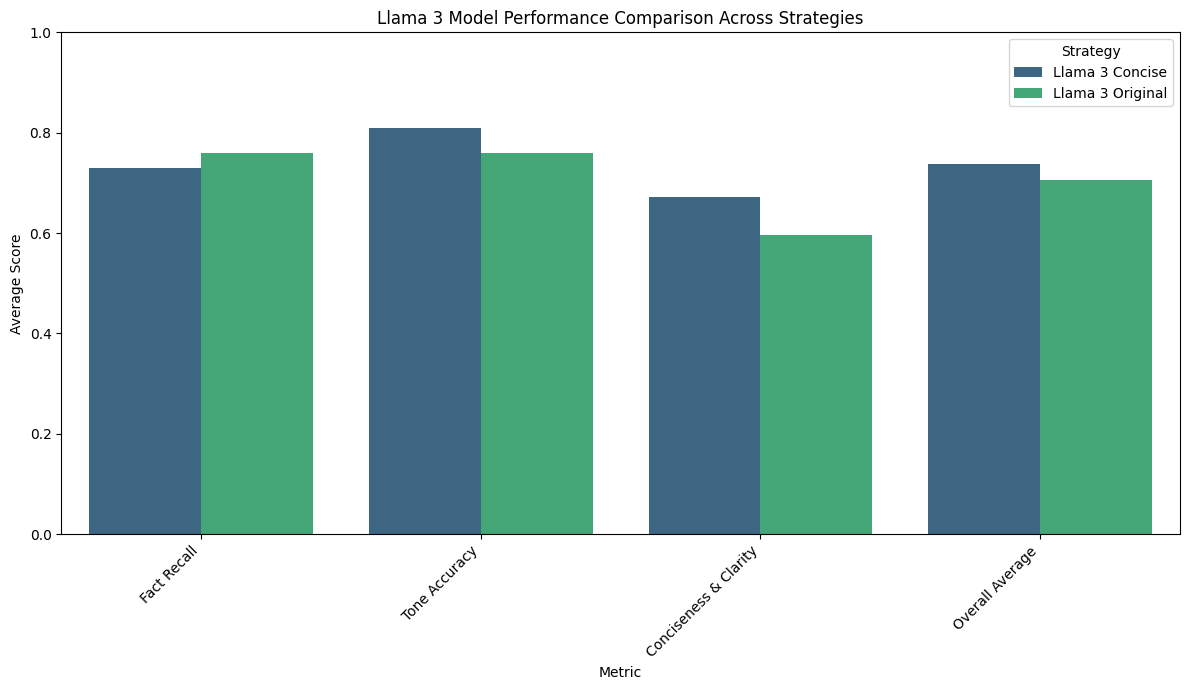

In [93]:
# Calculate and display average scores for both Llama 3 Original and Concise strategies
print("\n--- Overall Average Scores Comparison ---")

average_scores_by_strategy = df_results.groupby('strategy_name')[['metric1_score', 'metric2_score', 'metric3_score', 'average_score']].mean()
print(average_scores_by_strategy)

# Visualization for Llama 3's performance
import matplotlib.pyplot as plt
import seaborn as sns

comparison_metrics = ['metric1_score', 'metric2_score', 'metric3_score', 'average_score']
metric_labels = ['Fact Recall', 'Tone Accuracy', 'Conciseness & Clarity', 'Overall Average']

df_plot = average_scores_by_strategy.reset_index().melt(id_vars='strategy_name', value_vars=comparison_metrics, var_name='Metric', value_name='Score')
df_plot['Metric'] = df_plot['Metric'].map(dict(zip(comparison_metrics, metric_labels))) # Map to readable labels

plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='strategy_name', data=df_plot, palette='viridis')
plt.ylim(0, 1) # Scores are normalized between 0 and 1
plt.title('Llama 3 Model Performance Comparison Across Strategies')
plt.ylabel('Average Score')
plt.xlabel('Metric')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Strategy')
plt.tight_layout()
plt.show()